In [49]:
import sys

sys.path.append("..")

In [50]:
import os
import copy
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import join as pjoin

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn

from einops import rearrange

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from utils.misc import load_config, load_model_from_checkpoint, precision_recall_f1_score
from datasets.data_preparation import prepare_data
from datasets.utils import scale_data, create_patches

In [51]:
exp_path = '../results/dl.vit/2023-09-16 17Hr 37Min 07Sec IST+0530'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [52]:
trainer_config = config['trainer']
data_config = config['data']

model_name = config['model']['__name__']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
lithology_classes = data_config['lithology_classes']

config['root'] = '..'

In [53]:
config['model']['return_attention_map'] = False

In [54]:
if model_name.startswith('dl'):
    if model_name.endswith('vit'):
        if config['model']['autoregressive']:
            print('Using ViT Auto Regressor')
            from model.vit_autoregressor import build_model
            from engine.autoregressor import validation_engine as blind_engine
        else:
            print('Using ViT')
            from model.vit import build_model
            from engine.vit import validation_engine as blind_engine
    elif model_name.endswith('ann'):
        print('Using ANN')
        from model.ann import build_model
        from engine.vit import validation_engine as blind_engine

model = build_model(config)

Using ViT Auto Regressor
Building the model...


In [55]:
from peft import LoraConfig, get_peft_model

if config['model']['use_lora']:
     print('Using LORA')
     lora_config = LoraConfig(**config['model']['lora'])
     model = get_peft_model(model, lora_config)
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
else:
     print('Not using LORA')
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
model = model.to(device)

Not using LORA
Loading model from checkpoint...


In [56]:
X = pd.read_hdf(pjoin('..', config['data']['processed_data_path'], config['data']['x_file_name']))
Y = pd.read_hdf(pjoin('..', config['data']['processed_data_path'], config['data']['y_file_name']))

well_name = '00-12-04-072-06W4-0'

well_x = X[X.UWI == well_name]
well_y = Y[X.UWI == well_name]

well_depth = well_x.DEPT

well_x.drop(config['data']['drop_columns'], axis=1, inplace=True)

config['trainer']['experiment_path'] = '../'+config['trainer']['experiment_path']

well_x = scale_data(well_x, config, test=True, save=False)

if data_config['patch_based']:
    num_features = well_x.shape[1] - 1
    x_patches, y_patches = create_patches(well_x, well_y, [well_name], config['data'], num_features)
    num_classes = len(config['data']['lithology_classes'])
    x_train = torch.tensor(x_patches).float()
    y_train = torch.tensor(y_patches)

/tmp/ipykernel_28269/3138948583.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_x.drop(config['data']['drop_columns'], axis=1, inplace=True)
/home/nasim/phd/petro_AViT/notebooks/../datasets/utils.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = scaler.transform(X[col].values.reshape(-1, 1))
/home/nasim/phd/petro_AViT/notebooks/../datasets/utils.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

Loading scaler for GR...
Loading scaler for NPHI...
Loading scaler for DPHI...
Loading scaler for ILD...
Loading scaler for VSH...


Creating Patches: 100%|██████████| 1/1 [00:00<00:00, 429.13it/s]


In [57]:
regression_criterion = nn.MSELoss()
classification_criterion = nn.CrossEntropyLoss()

In [58]:
model.eval()
train_correct = 0
gt, pred = [], []
batch_inputs = x_train.to(device)
batch_labels = y_train.to(device)
outputs = torch.zeros((batch_inputs.shape[0], batch_inputs.shape[1], num_classes+2)).to(device)
vit_embedding = None
with torch.no_grad():
    for step in range(patch_size):
        lith_output, phi_output, sw_output, vit_embedding  = model(batch_inputs, outputs, step)
        next_token = torch.cat([lith_output, phi_output, sw_output], axis = -1)
        updated_initilizer = outputs.clone()
        updated_initilizer[:, step, :] = next_token
        outputs = updated_initilizer
        
lith_batch_labels = batch_labels[:, :, 0]
phi_output_labels = batch_labels[:, :, 1:2]
sw_output_labels = batch_labels[:, :, 2:]

lith_output = outputs[:, :, :num_classes]
phi_output = outputs[:, :, num_classes:num_classes+1]
sw_output = outputs[:, :, num_classes+1:]
predicted = torch.argmax(nn.Softmax(dim = -1)(lith_output), dim=-1)

lith_batch_labels = lith_batch_labels.long()

outputs_ = rearrange(lith_output, 'b n d -> b d n')
lith_loss = classification_criterion(outputs_, lith_batch_labels)

phi_loss = regression_criterion(phi_output, phi_output_labels)
sw_loss = regression_criterion(sw_output, sw_output_labels)

train_correct += (((lith_batch_labels == predicted).sum(-1).float().mean().item())/batch_inputs.shape[1])*100

gt.append(lith_batch_labels.cpu())
pred.append(predicted.cpu())

cm = confusion_matrix(torch.cat(gt, dim=0).view(-1), torch.cat(pred, dim=0).view(-1))

In [59]:
predicted_well_lith = torch.cat([predicted[i] for i in range(predicted.shape[0])], dim=0)
gt_well_lith = torch.cat([lith_batch_labels[i] for i in range(lith_batch_labels.shape[0])], dim=0)

predicted_well_phi = torch.cat([phi_output[i] for i in range(phi_output.shape[0])], dim=0)
gt_well_phi = torch.cat([phi_output_labels[i] for i in range(phi_output_labels.shape[0])], dim=0)

predicted_well_sw = torch.cat([sw_output[i] for i in range(sw_output.shape[0])], dim=0)
gt_well_sw = torch.cat([sw_output_labels[i] for i in range(sw_output_labels.shape[0])], dim=0)

In [60]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [61]:
class_gt_color_dict = {0: '#3a4cc0', 1: '#8daffd', 2: '#f39879', 3: '#b30326', 4: '#000000', 5: '#dddcdb'}
class_pred_color_dict = copy.deepcopy(class_gt_color_dict)

gt_not = list(set(list(range(num_classes))).difference(set(gt_well_lith.unique().cpu().numpy().tolist())))
pred_not = list(set(list(range(num_classes))).difference(set(predicted_well_lith.unique().cpu().numpy().tolist())))

[class_gt_color_dict.pop(i) for i in gt_not]
[class_pred_color_dict.pop(i) for i in pred_not]

class_color_gt = [class_gt_color_dict[i] for i in class_gt_color_dict]
class_color_pred = [class_pred_color_dict[i] for i in class_pred_color_dict]
cmap_facies_orig = colors.ListedColormap(class_color_gt, 'indexed')
cmap_facies_pred = colors.ListedColormap(class_color_pred, 'indexed')

lithology_classes_inverted = {v: k for k, v in lithology_classes.items()}
labels = [lithology_classes_inverted[i] for i in class_pred_color_dict]

In [62]:
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

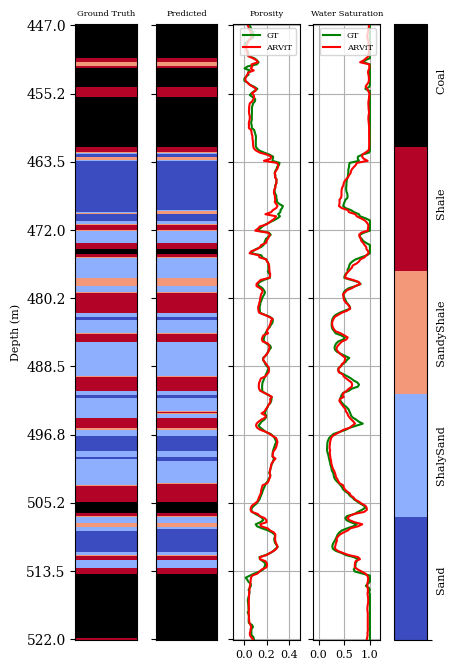

In [63]:
_, ax = plt.subplots(1, 5, figsize=(5, 8), sharey=True)
predicted_well_lith_repeat = predicted_well_lith.reshape(-1, 1).repeat(1, 30)
gt_well_lith_repeat = gt_well_lith.reshape(-1, 1).repeat(1, 30)

well_patch = well_depth.iloc[:300]
start, end = well_patch.iloc[0], well_patch.iloc[-1]

im = ax[0].imshow(gt_well_lith_repeat.cpu(), cmap=cmap_facies_orig)
ax[0].set_title('Ground Truth', fontsize=6)
ax[0].set_yticks(np.linspace(0, gt_well_lith.shape[0]-1, 10,))
ax[0].set_yticklabels(np.linspace(start, end, 10,).astype(np.float16), fontsize=10)
ax[0].set_ylabel('Depth (m)', fontsize=8)

ax[1].imshow(predicted_well_lith_repeat.cpu(), cmap=cmap_facies_pred)
ax[1].set_title('Predicted', fontsize=6)


ax[2].plot(gt_well_phi.cpu(), list(range(gt_well_phi.shape[0])), label='GT', color='green')
ax[2].plot(predicted_well_phi.cpu(), list(range(predicted_well_phi.shape[0])), label='ARViT', color='red')
ax[2].set_title('Porosity', fontsize=6)
ax[2].legend(fontsize=6)
ax[2].set_xlim([-0.1, 0.5])
ax[2].tick_params(axis='x', labelsize=8)
ax[2].set_xticks([0, 0.2, 0.4])
ax[2].grid()

ax[3].plot(gt_well_sw.cpu(), list(range(gt_well_sw.shape[0])), label='GT', color='green')
ax[3].plot(predicted_well_sw.cpu(), list(range(predicted_well_sw.shape[0])), label='ARViT', color='red')
ax[3].set_title('Water Saturation', fontsize=6)
ax[3].legend(fontsize=6)
ax[3].set_xlim([-0.1, 1.2])
ax[3].tick_params(axis='x', labelsize=8)
ax[3].set_xticks([0, 0.5, 1])
ax[3].grid()

ax[0].set_xticks([])
ax[1].set_xticks([])

divider = make_axes_locatable(ax[-1])
cax = divider.append_axes("left", size="100%", pad=0)
cbar=plt.colorbar(im, cax=cax,)
cbar.set_ticks(range(0,1))
cbar.set_ticklabels('')
cbar.set_label('Sand                       ShalySand                 SandyShale                       Shale                           Coal', rotation=90, labelpad=0, fontsize=8)
ax[-1].axis('off')
# plt.savefig(f"{well_name}_results.jpeg", dpi = 400, bbox_inches='tight')
plt.show()